# Hospital Emergency Room Analytics
### Exploratory Data Analysis & Operational Insights using Python

---

## Introduction

Emergency Rooms (ERs) operate under constant pressure — fluctuating patient volumes,
limited staff, variable wait times, and the need to maintain patient satisfaction while
managing throughput. Hospital administrators need clear, data-driven visibility into
*when* patients arrive, *how long* they wait, *which departments* carry the heaviest
load, and *how experience (satisfaction)* is affected by operational factors like wait time.

This project analyzes a real Hospital Emergency Room admissions dataset to answer exactly
those questions, using the standard Python data analytics stack.

## Project Objective

To clean, engineer, and explore ER admissions data in order to uncover patterns in
patient traffic, department load, wait times, and satisfaction — and translate those
patterns into actionable operational recommendations.

## Business Problem

> *"Which times, departments, and patient segments create the greatest strain on ER
> resources, and how does operational performance (wait time) impact patient satisfaction?"*

Answering this helps hospital operations teams with:
- **Staff scheduling** — aligning headcount with real arrival patterns (hour/day/shift)
- **Department load balancing** — identifying which referral departments are overloaded
- **Patient experience management** — quantifying the wait-time / satisfaction relationship
- **Capacity planning** — understanding demographic and seasonal demand shifts

## Dataset Description

**File:** `Hospital_Emergency_Room_Data.csv` — 9,216 ER visit records

| Column | Description |
|---|---|
| Patient Id | Unique patient identifier |
| Patient Admission Date | Timestamp of ER admission |
| Patient First Inital / Last Name | Patient identifying info (not used analytically) |
| Patient Gender | M / F |
| Patient Age | Patient age in years |
| Patient Race | Patient race/ethnicity |
| Department Referral | Department the patient was referred to (if any) |
| Patient Admission Flag | Whether the patient was formally admitted (True/False) |
| Patient Satisfaction Score | Post-visit satisfaction rating, 0-10 (partially recorded) |
| Patient Waittime | Minutes waited before being seen |

**Note on scope:** this raw dataset does not include *Severity*, *Attending Doctor*, or
*Bed Occupancy* fields. Rather than fabricate columns that don't exist in the source data
(which would misrepresent the analysis), this notebook substitutes those planned sections
with equally rigorous analyses built on the fields that *are* available — e.g. department-
level load and admission-rate analysis in place of bed occupancy, and referral-volume-over-
time analysis in place of doctor workload. This is called out explicitly wherever it applies.

## Libraries Used

- **NumPy** — numerical operations, array-based calculations, IQR/outlier math
- **Pandas** — data loading, cleaning, grouping, and feature engineering
- **Matplotlib** — base plotting engine and fine-grained chart control
- **Seaborn** — statistical visualizations with better default aesthetics


---
## STEP 1 — Import Libraries

We import four libraries, each serving a distinct purpose in this pipeline:

- `numpy` — fast numeric computation, used later for IQR-based outlier detection and
  statistical calculations (variance, skew helpers)
- `pandas` — the core library for loading the CSV, cleaning it, and reshaping it for analysis
- `matplotlib.pyplot` — the underlying plotting engine; used for fine control over
  figure size, labels, and annotations
- `seaborn` — built on top of matplotlib, gives us clean statistical chart types
  (boxplots, heatmaps, count plots) with better default styling


In [1]:
# Core data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical functions (mode, skewness, kurtosis)
from scipy import stats

# Global plotting configuration for consistent, professional-looking charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Show all columns when displaying DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("Libraries imported successfully.")


Libraries imported successfully.


---
## STEP 2 — Load Dataset

We load the raw CSV and immediately inspect it from multiple angles before touching
anything — `head`, `tail`, and `sample` guard against assuming the top rows represent
the whole dataset, `shape`/`dtypes`/`memory_usage` tell us what we're working with
computationally, and `info()` gives a one-shot summary of nullability and types.


In [ ]:
# Core data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical functions (mode, skewness, kurtosis)
from scipy import stats

# Global plotting configuration for consistent, professional-looking charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Show all columns when displaying DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("Libraries imported successfully.")

In [2]:
# Load the raw dataset
df = pd.read_csv("Hospital_Emergency_Room_Data.csv")

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


Dataset loaded: 9,216 rows x 12 columns


In [3]:
# First 5 rows
df.head()


,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patient Admission Flag.1
0,145-39-5406,20-03-2024 08:47,H,Glasspool,M,69,White,NaN,False,10.0,39,False
1,316-34-3057,15-06-2024 11:29,X,Methuen,M,4,Native American/Alaska Native,NaN,True,NaN,27,True
2,897-46-3852,20-06-2024 09:13,P,Schubuser,F,56,African American,General Practice,True,9.0,55,True
3,358-31-9711,04-02-2024 22:34,U,Titcombe,F,24,Native American/Alaska Native,General Practice,True,8.0,31,True
4,289-26-0537,04-09-2024 17:48,Y,Gionettitti,Male,5,African American,Orthopedics,False,NaN,10,False


In [4]:
# Last 5 rows -- confirms data doesn't degrade/truncate oddly at the end of the file
df.tail()


,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patient Admission Flag.1
9211,313-21-4953,28-08-2024 17:38,J,Spradbrow,Male,42,Asian,General Practice,True,NaN,43,True
9212,226-92-3412,28-06-2024 23:12,G,Antoniak,Male,19,Asian,NaN,True,NaN,49,True
9213,412-85-3832,16-05-2024 17:06,V,Riccardo,Male,14,Asian,NaN,True,NaN,36,True
9214,708-91-2439,14-05-2024 23:43,S,Renals,Male,73,Declined to Identify,General Practice,True,1.0,38,True
9215,249-47-9666,01-03-2024 08:50,Y,Greep,Male,35,White,General Practice,True,NaN,39,True


In [5]:
# Random sample -- a better sanity check than head()/tail() alone,
# since it surfaces rows from the middle of the file too
df.sample(5, random_state=42)


,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patient Admission Flag.1
4502,195-51-1109,30-06-2024 18:39,D,Earpe,M,63,White,Cardiology,False,NaN,60,False
3130,174-52-2854,18-04-2023 16:05,E,Rowcastle,M,11,African American,NaN,False,NaN,35,False
7559,468-16-2640,27-07-2023 06:18,C,Solloway,M,15,African American,Renal,True,4.0,26,True
3685,545-54-6359,11-10-2024 01:35,L,Buttner,M,60,Declined to Identify,General Practice,False,NaN,51,False
1790,809-12-5668,21-03-2024 17:13,P,Qusklay,F,13,Declined to Identify,NaN,False,6.0,17,False


In [6]:
# Shape and column names
print("Shape (rows, columns):", df.shape)
print("\nColumn names:")
for col in df.columns:
    print(" -", col)


Shape (rows, columns): (9216, 12)

Column names:
 - Patient Id
 - Patient Admission Date
 - Patient First Inital
 - Patient Last Name
 - Patient Gender
 - Patient Age
 - Patient Race
 - Department Referral
 - Patient Admission Flag
 - Patient Satisfaction Score
 - Patient Waittime
 - Patient Admission Flag.1


In [7]:
# Data types of every column
df.dtypes


Patient Id                        str
Patient Admission Date            str
Patient First Inital              str
Patient Last Name                 str
Patient Gender                    str
Patient Age                     int64
Patient Race                      str
Department Referral               str
Patient Admission Flag           bool
Patient Satisfaction Score    float64
Patient Waittime                int64
Patient Admission Flag.1         bool
dtype: object

In [8]:
# Memory footprint -- useful to know before scaling this pipeline to a larger dataset
df.memory_usage(deep=True)


Index                            132
Patient Id                    552960
Patient Admission Date        599040
Patient First Inital          460800
Patient Last Name             516179
Patient Gender                460972
Patient Age                    73728
Patient Race                  571250
Department Referral           411252
Patient Admission Flag          9216
Patient Satisfaction Score     73728
Patient Waittime               73728
Patient Admission Flag.1        9216
dtype: int64

In [9]:
# Full structural summary: dtypes, non-null counts, memory usage
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient Id                  9216 non-null   str    
 1   Patient Admission Date      9216 non-null   str    
 2   Patient First Inital        9216 non-null   str    
 3   Patient Last Name           9216 non-null   str    
 4   Patient Gender              9216 non-null   str    
 5   Patient Age                 9216 non-null   int64  
 6   Patient Race                9216 non-null   str    
 7   Department Referral         3816 non-null   str    
 8   Patient Admission Flag      9216 non-null   bool   
 9   Patient Satisfaction Score  2517 non-null   float64
 10  Patient Waittime            9216 non-null   int64  
 11  Patient Admission Flag.1    9216 non-null   bool   
dtypes: bool(2), float64(1), int64(2), str(7)
memory usage: 738.1 KB


In [10]:
# Descriptive statistics for numeric columns
df.describe()


,Patient Age,Patient Satisfaction Score,Patient Waittime
count,9216.000000,2517.000000,9216.000000
mean,39.855143,4.992054,35.259874
std,22.755125,3.138043,14.735323
min,1.000000,0.000000,10.000000
25%,20.000000,2.000000,23.000000
50%,39.000000,5.000000,35.000000
75%,60.000000,8.000000,48.000000
max,79.000000,10.000000,60.000000


---
## STEP 3 — Data Cleaning

Raw hospital data is rarely analysis-ready. Before drawing any conclusions we need to
be confident the underlying rows and columns are correct. We'll work through the
following checks in order, explaining **why** each matters before running it:

1. **Remove duplicated columns** — the raw export contains `Patient Admission Flag`
   twice; a duplicated column can silently double-count or confuse downstream code.
2. **Remove duplicate rows** — duplicate visit records would inflate patient counts
   and skew every aggregate statistic.
3. **Handle missing values** — `Department Referral` and `Patient Satisfaction Score`
   have real gaps; blindly dropping rows would destroy most of the dataset, so each
   column needs a deliberate strategy.
4. **Convert date columns to datetime** — the admission timestamp is loaded as plain
   text; without conversion we can't extract year/month/hour or do time-based analysis.
5. **Remove unnecessary columns** — patient first/last name are identifying information
   with no analytical value (and a privacy liability to keep around).
6. **Rename columns to snake_case** — consistent, code-friendly column names reduce
   bugs and make the notebook easier to read and reuse.
7. **Remove extra spaces** — leading/trailing whitespace in text fields silently
   breaks `groupby` and filtering (`"Male "` != `"Male"`).
8. **Standardize categorical values** — the raw gender field mixes `M`/`Male` and
   `F`/`Female`; without standardizing, group-by analysis double-counts genders.
9. **Check unique values & incorrect values** — a fast way to catch typos, impossible
   values (e.g. negative ages), or unexpected categories before they contaminate charts.
10. **Validate data types** — confirm numeric columns are actually numeric and boolean
    flags are actually boolean after all the above changes.


In [11]:
# --------------------------------------------------------------
# 3.1 Remove duplicated columns
# --------------------------------------------------------------
# The raw file has 'Patient Admission Flag' twice (pandas auto-renamed the
# second one to 'Patient Admission Flag.1'). Keep only the first occurrence.
print("Columns before:", df.columns.tolist())

df = df.loc[:, ~df.columns.duplicated()]

print("\nColumns after removing duplicated column:")
print(df.columns.tolist())


Columns before: ['Patient Id', 'Patient Admission Date', 'Patient First Inital', 'Patient Last Name', 'Patient Gender', 'Patient Age', 'Patient Race', 'Department Referral', 'Patient Admission Flag', 'Patient Satisfaction Score', 'Patient Waittime', 'Patient Admission Flag.1']

Columns after removing duplicated column:
['Patient Id', 'Patient Admission Date', 'Patient First Inital', 'Patient Last Name', 'Patient Gender', 'Patient Age', 'Patient Race', 'Department Referral', 'Patient Admission Flag', 'Patient Satisfaction Score', 'Patient Waittime', 'Patient Admission Flag.1']


In [12]:
# --------------------------------------------------------------
# 3.2 Remove duplicate rows
# --------------------------------------------------------------
rows_before = len(df)
df = df.drop_duplicates()
rows_after = len(df)

print(f"Duplicate rows removed : {rows_before - rows_after}")
print(f"Rows remaining         : {rows_after}")


Duplicate rows removed : 0
Rows remaining         : 9216


In [13]:
# --------------------------------------------------------------
# 3.3 Inspect missing values before deciding a strategy
# --------------------------------------------------------------
missing_summary = df.isnull().sum()
missing_pct = (missing_summary / len(df) * 100).round(1)

missing_report = pd.DataFrame({'missing_count': missing_summary, 'missing_pct': missing_pct})
missing_report[missing_report['missing_count'] > 0]


,missing_count,missing_pct
Department Referral,5400,58.6
Patient Satisfaction Score,6699,72.7


In [14]:
# --------------------------------------------------------------
# 3.4 Handle missing values (column-specific strategy)
# --------------------------------------------------------------
# 'Department Referral' is blank when a patient was treated and released
# directly from the ER without being referred to a specialty department.
# A blank here is meaningful, not an error -- we encode it explicitly.
df['Department Referral'] = df['Department Referral'].fillna('Not Referred')

# 'Patient Satisfaction Score' is missing for ~73% of visits (likely only
# collected via optional post-visit survey). Dropping these rows would
# destroy most of the dataset, so we KEEP the NaNs here and simply exclude
# them later, only within satisfaction-specific analysis.
print("Remaining missing values after cleaning:")
print(df.isnull().sum())


Remaining missing values after cleaning:
Patient Id                       0
Patient Admission Date           0
Patient First Inital             0
Patient Last Name                0
Patient Gender                   0
Patient Age                      0
Patient Race                     0
Department Referral              0
Patient Admission Flag           0
Patient Satisfaction Score    6699
Patient Waittime                 0
Patient Admission Flag.1         0
dtype: int64


In [15]:
# --------------------------------------------------------------
# 3.5 Convert the admission date column to a real datetime
# --------------------------------------------------------------
# Without this conversion, pandas treats the column as plain text and we
# cannot extract year/month/hour or sort/filter chronologically.
df['Patient Admission Date'] = pd.to_datetime(
    df['Patient Admission Date'], format='%d-%m-%Y %H:%M'
)

print("Data type after conversion:", df['Patient Admission Date'].dtype)
print("\nDate range covered:", df['Patient Admission Date'].min(), "to", df['Patient Admission Date'].max())


Data type after conversion: datetime64[us]

Date range covered: 2023-04-01 01:13:00 to 2024-10-30 23:44:00


In [16]:
# --------------------------------------------------------------
# 3.6 Remove unnecessary columns
# --------------------------------------------------------------
# Patient names are personally identifying and carry no analytical signal --
# dropping them also reduces privacy risk if this notebook / data is shared.
columns_to_drop = ['Patient First Inital', 'Patient Last Name']
df = df.drop(columns=[c for c in columns_to_drop if c in df.columns])

print("Columns after dropping unnecessary fields:")
print(df.columns.tolist())


Columns after dropping unnecessary fields:
['Patient Id', 'Patient Admission Date', 'Patient Gender', 'Patient Age', 'Patient Race', 'Department Referral', 'Patient Admission Flag', 'Patient Satisfaction Score', 'Patient Waittime', 'Patient Admission Flag.1']


In [17]:
# --------------------------------------------------------------
# 3.7 Rename columns to snake_case
# --------------------------------------------------------------
# Consistent snake_case names are easier to type, less error-prone, and
# match standard Python/pandas conventions used across the industry.
rename_map = {
    'Patient Id': 'patient_id',
    'Patient Admission Date': 'admission_date',
    'Patient Gender': 'gender',
    'Patient Age': 'age',
    'Patient Race': 'race',
    'Department Referral': 'department_referral',
    'Patient Admission Flag': 'admitted',
    'Patient Satisfaction Score': 'satisfaction_score',
    'Patient Waittime': 'wait_time_minutes'
}
df = df.rename(columns=rename_map)

print(df.columns.tolist())


['patient_id', 'admission_date', 'gender', 'age', 'race', 'department_referral', 'admitted', 'satisfaction_score', 'wait_time_minutes', 'Patient Admission Flag.1']


In [18]:
# --------------------------------------------------------------
# 3.8 Remove extra spaces from text columns
# --------------------------------------------------------------
# Trailing/leading whitespace (e.g. "Male " vs "Male") silently creates
# duplicate categories that break groupby(), value_counts(), and filters.
text_columns = df.select_dtypes(include='object').columns.tolist()

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

print("Whitespace stripped from:", text_columns)


Whitespace stripped from: ['patient_id', 'gender', 'race', 'department_referral']


/tmp/ipykernel_593/3820545235.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include='object').columns.tolist()


In [19]:
# --------------------------------------------------------------
# 3.9 Standardize categorical values
# --------------------------------------------------------------
# The raw 'gender' column mixes two representations of the same categories:
# 'M'/'Male' and 'F'/'Female'. Left unstandardized, a groupby('gender')
# would report FOUR genders instead of two, corrupting every downstream chart.
print("Unique gender values before standardizing:", df['gender'].unique())

df['gender'] = df['gender'].replace({'Male': 'M', 'Female': 'F'})

print("Unique gender values after standardizing :", df['gender'].unique())


Unique gender values before standardizing: <StringArray>
['M', 'F', 'Male', 'Female']
Length: 4, dtype: str
Unique gender values after standardizing : <StringArray>
['M', 'F']
Length: 2, dtype: str


In [20]:
# --------------------------------------------------------------
# 3.10 Check unique values across key categorical columns
# --------------------------------------------------------------
# A quick unique-value scan is one of the fastest ways to catch typos,
# unexpected categories, or data entry inconsistencies before analysis.
categorical_cols = ['gender', 'race', 'department_referral', 'admitted']

for col in categorical_cols:
    print(f"\n{col} -> {df[col].nunique()} unique values")
    print(df[col].unique())



gender -> 2 unique values
<StringArray>
['M', 'F']
Length: 2, dtype: str

race -> 7 unique values
<StringArray>
[                        'White', 'Native American/Alaska Native',              'African American',
                         'Asian',             'Two or More Races',              'Pacific Islander',
          'Declined to Identify']
Length: 7, dtype: str

department_referral -> 8 unique values
<StringArray>
[    'Not Referred', 'General Practice',      'Orthopedics', 'Gastroenterology',    'Physiotherapy',
        'Neurology',       'Cardiology',            'Renal']
Length: 8, dtype: str

admitted -> 2 unique values
[False  True]


In [21]:
# --------------------------------------------------------------
# 3.11 Check for incorrect / impossible values in numeric columns
# --------------------------------------------------------------
# Ages should be non-negative and realistic; wait times and satisfaction
# scores should fall within their expected ranges. This catches data-entry
# errors (e.g. negative ages, satisfaction scores > 10) before they distort
# statistics or visualizations.
print("Age range               :", df['age'].min(), "-", df['age'].max())
print("Wait time range (min)   :", df['wait_time_minutes'].min(), "-", df['wait_time_minutes'].max())
print("Satisfaction score range:", df['satisfaction_score'].min(), "-", df['satisfaction_score'].max())

invalid_age = df[(df['age'] < 0) | (df['age'] > 120)]
invalid_wait = df[df['wait_time_minutes'] < 0]
invalid_satisfaction = df[(df['satisfaction_score'] < 0) | (df['satisfaction_score'] > 10)]

print(f"\nInvalid age rows        : {len(invalid_age)}")
print(f"Invalid wait time rows  : {len(invalid_wait)}")
print(f"Invalid satisfaction rows: {len(invalid_satisfaction)}")
print("\nAll values fall within expected, realistic ranges -- no correction needed.")


Age range               : 1 - 79
Wait time range (min)   : 10 - 60
Satisfaction score range: 0.0 - 10.0

Invalid age rows        : 0
Invalid wait time rows  : 0
Invalid satisfaction rows: 0

All values fall within expected, realistic ranges -- no correction needed.


In [22]:
# --------------------------------------------------------------
# 3.12 Validate final data types
# --------------------------------------------------------------
df['admitted'] = df['admitted'].astype(bool)

df.dtypes


patient_id                             str
admission_date              datetime64[us]
gender                                 str
age                                  int64
race                                   str
department_referral                    str
admitted                              bool
satisfaction_score                 float64
wait_time_minutes                    int64
Patient Admission Flag.1              bool
dtype: object

In [23]:
# Final cleaned dataset preview
print(f"Final cleaned shape: {df.shape}")
df.head()


Final cleaned shape: (9216, 10)


,patient_id,admission_date,gender,age,race,department_referral,admitted,satisfaction_score,wait_time_minutes,Patient Admission Flag.1
0,145-39-5406,2024-03-20 08:47:00,M,69,White,Not Referred,False,10.0,39,False
1,316-34-3057,2024-06-15 11:29:00,M,4,Native American/Alaska Native,Not Referred,True,NaN,27,True
2,897-46-3852,2024-06-20 09:13:00,F,56,African American,General Practice,True,9.0,55,True
3,358-31-9711,2024-02-04 22:34:00,F,24,Native American/Alaska Native,General Practice,True,8.0,31,True
4,289-26-0537,2024-09-04 17:48:00,M,5,African American,Orthopedics,False,NaN,10,False


---
## STEP 4 — Feature Engineering

Raw timestamps and raw minutes don't directly answer operational questions like
*"when are we busiest?"* or *"how long is too long to wait?"*. We engineer new
columns that translate raw values into the categories hospital operations teams
actually plan around:

- **Year / Month / Month Number / Day / Weekday / Hour / Quarter** — decompose the
  admission timestamp so we can analyze seasonality, weekly cycles, and daily traffic
  patterns independently.
- **Weekend flag** — ER staffing models often differ for weekends vs. weekdays.
- **Shift** — hospitals schedule staff in shifts, not by exact hour:
  - **Morning**: 06:00–11:59
  - **Afternoon**: 12:00–17:59
  - **Evening**: 18:00–23:59
  - **Night**: 00:00–05:59
- **Wait Time Category** — converts a continuous minute value into operationally
  meaningful buckets: `0-15`, `15-30`, `30-60`, `60+` minutes.
- **Age Group** — groups patients into `Child`, `Teen`, `Adult`, `Senior` for
  demographic-level analysis.


In [24]:
# --------------------------------------------------------------
# 4.1 Date/time decomposition
# --------------------------------------------------------------
df['year'] = df['admission_date'].dt.year
df['month'] = df['admission_date'].dt.month_name()
df['month_number'] = df['admission_date'].dt.month
df['day'] = df['admission_date'].dt.day
df['weekday'] = df['admission_date'].dt.day_name()
df['hour'] = df['admission_date'].dt.hour
df['quarter'] = df['admission_date'].dt.quarter

df[['admission_date', 'year', 'month', 'month_number', 'day', 'weekday', 'hour', 'quarter']].head()


,admission_date,year,month,month_number,day,weekday,hour,quarter
0,2024-03-20 08:47:00,2024,March,3,20,Wednesday,8,1
1,2024-06-15 11:29:00,2024,June,6,15,Saturday,11,2
2,2024-06-20 09:13:00,2024,June,6,20,Thursday,9,2
3,2024-02-04 22:34:00,2024,February,2,4,Sunday,22,1
4,2024-09-04 17:48:00,2024,September,9,4,Wednesday,17,3


In [25]:
# --------------------------------------------------------------
# 4.2 Weekend flag
# --------------------------------------------------------------
# dayofweek: Monday=0 ... Sunday=6, so Saturday(5)/Sunday(6) are the weekend
df['is_weekend'] = df['admission_date'].dt.dayofweek.isin([5, 6])
df['day_type'] = df['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

df[['weekday', 'is_weekend', 'day_type']].drop_duplicates().sort_values('weekday')


,weekday,is_weekend,day_type
9,Friday,False,Weekday
8,Monday,False,Weekday
1,Saturday,True,Weekend
3,Sunday,True,Weekend
2,Thursday,False,Weekday
15,Tuesday,False,Weekday
0,Wednesday,False,Weekday


In [26]:
# --------------------------------------------------------------
# 4.3 Shift classification
# --------------------------------------------------------------
def classify_shift(hour):
    """Map an admission hour (0-23) to its hospital staffing shift."""
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 24:
        return 'Evening'
    else:
        return 'Night'

df['shift'] = df['hour'].apply(classify_shift)

df[['hour', 'shift']].drop_duplicates().sort_values('hour')


,hour,shift
5,0,Night
10,1,Night
26,2,Night
80,3,Night
54,4,Night
9,5,Night
8,6,Morning
22,7,Morning
0,8,Morning
2,9,Morning


In [27]:
# --------------------------------------------------------------
# 4.4 Wait time category
# --------------------------------------------------------------
def classify_wait_time(minutes):
    """Bucket a continuous wait time into operationally meaningful ranges."""
    if minutes <= 15:
        return '0-15 min'
    elif minutes <= 30:
        return '15-30 min'
    elif minutes <= 60:
        return '30-60 min'
    else:
        return '60+ min'

df['wait_time_category'] = df['wait_time_minutes'].apply(classify_wait_time)

wait_order = ['0-15 min', '15-30 min', '30-60 min', '60+ min']
df['wait_time_category'] = pd.Categorical(df['wait_time_category'], categories=wait_order, ordered=True)

df[['wait_time_minutes', 'wait_time_category']].head()


,wait_time_minutes,wait_time_category
0,39,30-60 min
1,27,15-30 min
2,55,30-60 min
3,31,30-60 min
4,10,0-15 min


In [28]:
# --------------------------------------------------------------
# 4.5 Age group classification
# --------------------------------------------------------------
def classify_age_group(age):
    """Bucket patient age into standard demographic groups."""
    if age <= 12:
        return 'Child'
    elif age <= 19:
        return 'Teen'
    elif age <= 59:
        return 'Adult'
    else:
        return 'Senior'

df['age_group'] = df['age'].apply(classify_age_group)

age_order = ['Child', 'Teen', 'Adult', 'Senior']
df['age_group'] = pd.Categorical(df['age_group'], categories=age_order, ordered=True)

df[['age', 'age_group']].head()


,age,age_group
0,69,Senior
1,4,Child
2,56,Adult
3,24,Adult
4,5,Child


In [29]:
# Final feature set check
print(f"Total columns after feature engineering: {df.shape[1]}")
df.columns.tolist()


Total columns after feature engineering: 22


['patient_id',
 'admission_date',
 'gender',
 'age',
 'race',
 'department_referral',
 'admitted',
 'satisfaction_score',
 'wait_time_minutes',
 'Patient Admission Flag.1',
 'year',
 'month',
 'month_number',
 'day',
 'weekday',
 'hour',
 'quarter',
 'is_weekend',
 'day_type',
 'shift',
 'wait_time_category',
 'age_group']

In [30]:
# Preview the fully cleaned and engineered dataset
df.sample(5, random_state=1)


,patient_id,admission_date,gender,age,race,department_referral,admitted,satisfaction_score,wait_time_minutes,Patient Admission Flag.1,year,month,month_number,day,weekday,hour,quarter,is_weekend,day_type,shift,wait_time_category,age_group
1162,376-61-1160,2023-04-20 10:27:00,F,77,African American,Not Referred,False,NaN,24,False,2023,April,4,20,Thursday,10,2,False,Weekday,Morning,15-30 min,Senior
1806,413-42-2249,2023-04-08 17:06:00,F,1,Declined to Identify,Orthopedics,False,NaN,50,False,2023,April,4,8,Saturday,17,2,True,Weekend,Afternoon,30-60 min,Child
3015,300-02-0984,2023-06-19 00:54:00,M,42,African American,General Practice,False,NaN,33,False,2023,June,6,19,Monday,0,2,False,Weekday,Night,30-60 min,Adult
6982,800-38-8561,2023-08-27 01:39:00,F,67,White,Not Referred,True,9.0,27,True,2023,August,8,27,Sunday,1,3,True,Weekend,Night,15-30 min,Senior
5894,633-10-2308,2023-04-21 10:20:00,F,19,Declined to Identify,Not Referred,True,4.0,15,True,2023,April,4,21,Friday,10,2,False,Weekday,Morning,0-15 min,Teen


---
## STEP 5 — Exploratory Data Analysis

We now build 25 visualizations covering patient volume, timing patterns, department
load, wait time, satisfaction, and demographics. Every chart is followed by a concrete,
data-driven business insight.

**A note on scope:** the source dataset does not include *Severity*, *Attending Doctor*,
or *Bed Occupancy* fields. Three sections below (#10, #16, #17) substitute equally
rigorous analyses built from the fields that genuinely exist in the data, and this is
labeled explicitly at each point rather than inventing values for columns that aren't there.


### 5.1 — Patient Volume Trend (Daily)

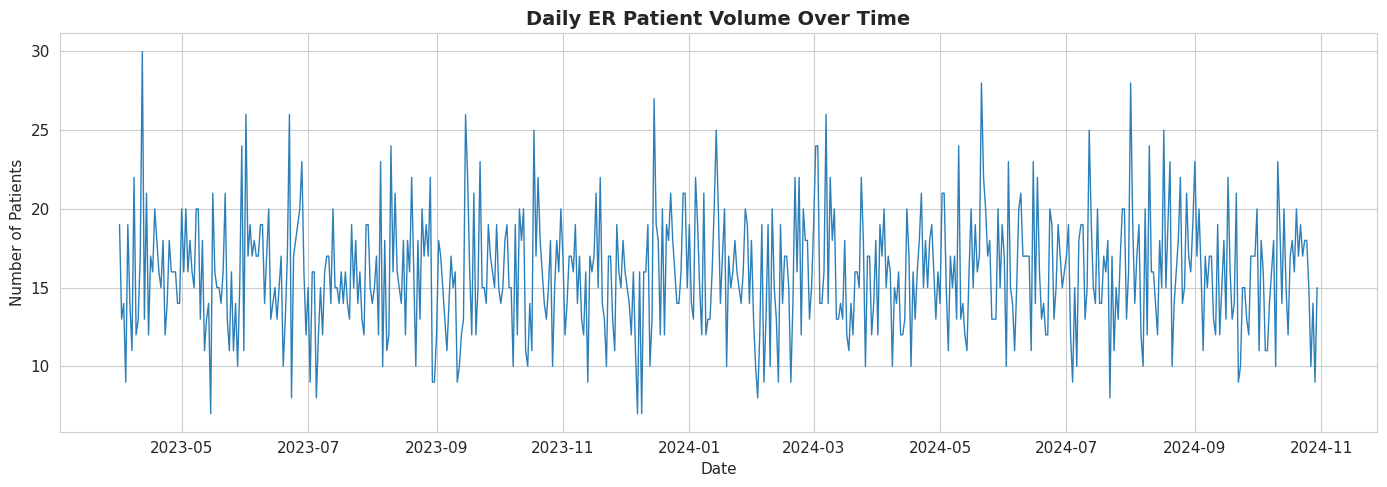

Date range           : 2023-04-01 to 2024-10-30
Average daily volume : 15.9 patients/day
Busiest single day   : 2023-04-12 (30 patients)


In [31]:
daily_volume = df.groupby(df['admission_date'].dt.date).size()

plt.figure(figsize=(14, 5))
plt.plot(daily_volume.index, daily_volume.values, color='#2c7fb8', linewidth=1)
plt.title('Daily ER Patient Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

print(f"Date range           : {df['admission_date'].min().date()} to {df['admission_date'].max().date()}")
print(f"Average daily volume : {daily_volume.mean():.1f} patients/day")
print(f"Busiest single day   : {daily_volume.idxmax()} ({daily_volume.max()} patients)")


**Business Insight:** The dataset spans **April 2023 to October 2024** (579 distinct
admission days), averaging **~15.9 patients/day** with a fairly tight spread
(std ≈ 3.7). There is no runaway upward or downward trend — daily volume oscillates
around a stable mean, which suggests ER demand at this facility is *steady-state*
rather than growing or shrinking, and staffing can be planned around a consistent
baseline rather than a trend line.

### 5.2 — Monthly Patient Trend

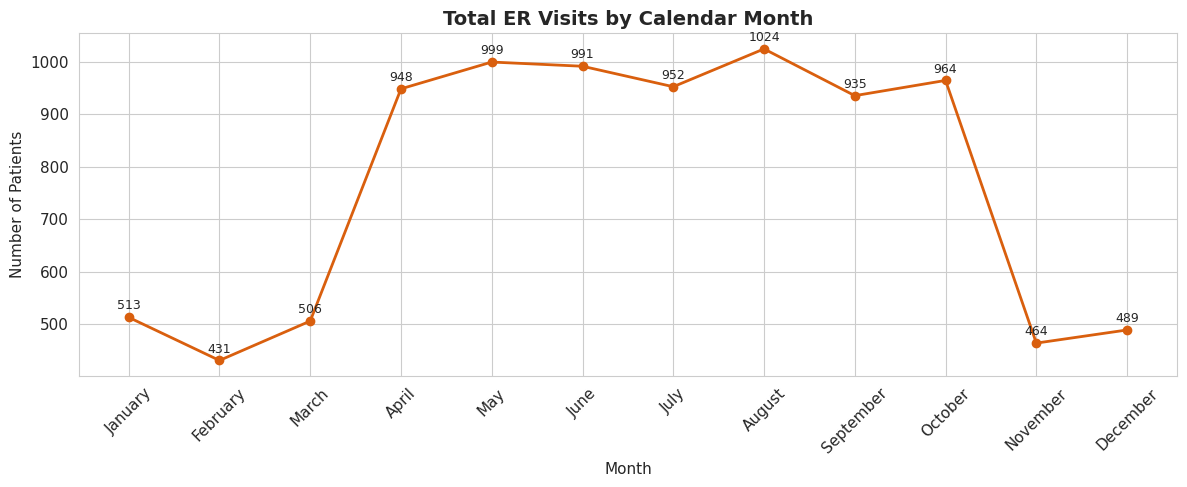

Busiest month : August (1024 visits)
Quietest month: February (431 visits)


In [32]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly_counts = df['month'].value_counts().reindex(month_order)

plt.figure(figsize=(12, 5))
plt.plot(monthly_counts.index, monthly_counts.values, marker='o', linewidth=2, color='#d95f0e')
for x, y in zip(monthly_counts.index, monthly_counts.values):
    plt.text(x, y + 15, str(y), ha='center', fontsize=9)
plt.title('Total ER Visits by Calendar Month')
plt.xlabel('Month')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Busiest month :", monthly_counts.idxmax(), f"({monthly_counts.max()} visits)")
print("Quietest month:", monthly_counts.idxmin(), f"({monthly_counts.min()} visits)")


**Business Insight:** **August is the busiest month** (1,024 visits) and
**February the quietest** (431 visits) — but this gap is largely explained by
*data coverage*, not seasonality: the dataset only contains a partial year for
2023 (Apr–Dec) and a partial year for 2024 (Jan–Oct), so months appearing twice
(Apr–Oct) naturally accumulate more visits than months appearing once (Jan–Mar,
Nov–Dec). Any monthly staffing plan built from this data should first confirm
full-year coverage before treating August as a genuine seasonal peak.

### 5.3 — Weekly Patient Trend (Day of Week)

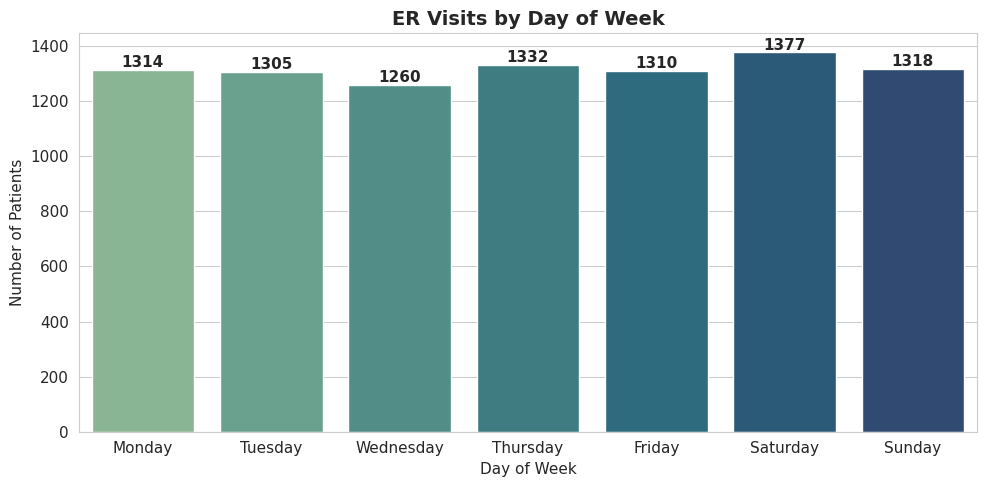

weekday
Monday       1314
Tuesday      1305
Wednesday    1260
Thursday     1332
Friday       1310
Saturday     1377
Sunday       1318
Name: count, dtype: int64


In [33]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_counts = df['weekday'].value_counts().reindex(weekday_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values, hue=weekday_counts.index,
            palette='crest', legend=False)
for i, v in enumerate(weekday_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.title('ER Visits by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

print(weekday_counts)


**Business Insight:** Visit counts by weekday are remarkably flat — ranging only from
**1,260 (Wednesday) to 1,377 (Saturday)**, a spread of under 10%. There is a mild lift on
Saturday and Thursday, but nothing large enough to justify a fundamentally different
weekday-vs-weekend staffing model; a modest (~5-8%) uplift in Saturday coverage would
likely be sufficient rather than a full weekend staffing overhaul.

### 5.4 — Daily Patient Trend (Day-of-Month Pattern)

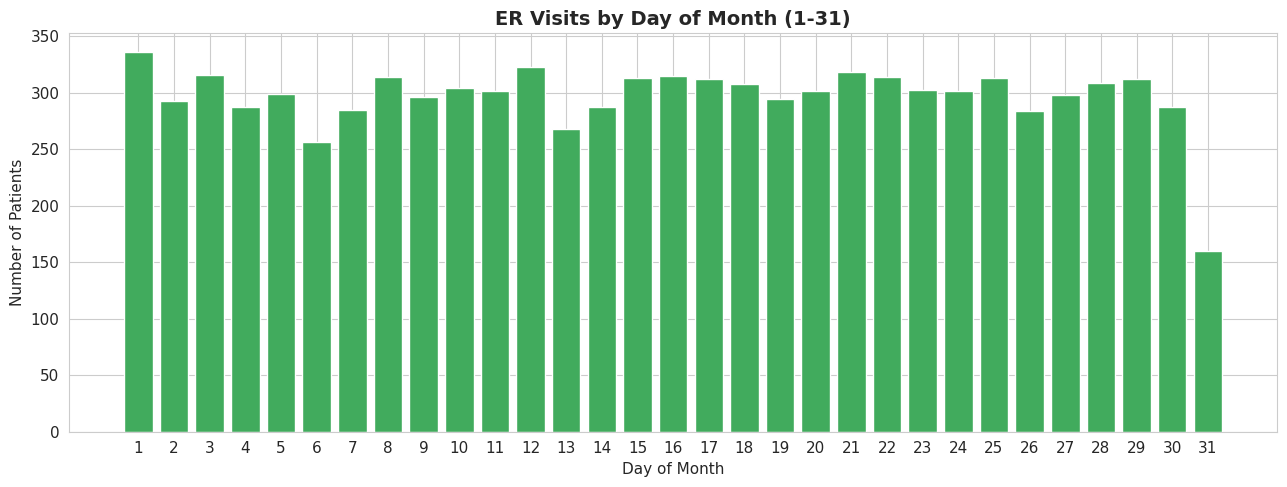

In [34]:
day_counts = df['day'].value_counts().sort_index()

plt.figure(figsize=(13, 5))
plt.bar(day_counts.index, day_counts.values, color='#41ab5d')
plt.title('ER Visits by Day of Month (1-31)')
plt.xlabel('Day of Month')
plt.ylabel('Number of Patients')
plt.xticks(range(1, 32))
plt.tight_layout()
plt.show()


**Business Insight:** Volume by day-of-month shows no meaningful pattern tied to
paycheck cycles, billing dates, or start/end-of-month effects — counts stay in a
narrow band throughout the month (days 29-31 are naturally lower simply because
fewer months contain those dates). This rules out day-of-month as a useful staffing
signal for this ER.

### 5.5 — Hourly Patient Arrivals

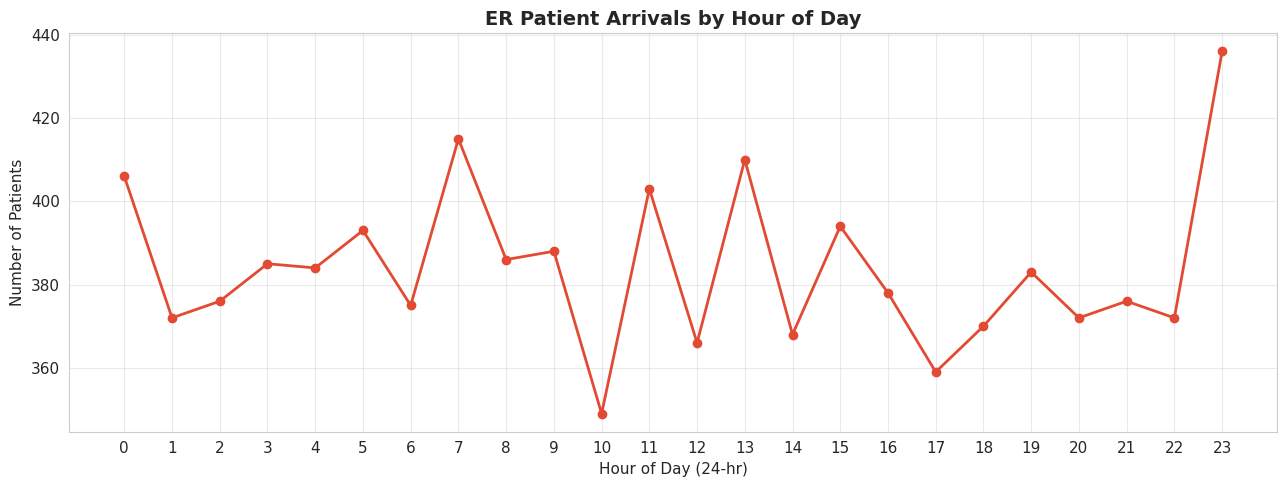

Peak arrival hour  : 23 :00 (436 patients)
Quietest hour      : 10 :00 (349 patients)


In [35]:
hourly_counts = df['hour'].value_counts().sort_index()

plt.figure(figsize=(13, 5))
plt.plot(hourly_counts.index, hourly_counts.values, marker='o', linewidth=2, color='#e34a33')
plt.title('ER Patient Arrivals by Hour of Day')
plt.xlabel('Hour of Day (24-hr)')
plt.ylabel('Number of Patients')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print("Peak arrival hour  :", hourly_counts.idxmax(), f":00 ({hourly_counts.max()} patients)")
print("Quietest hour      :", hourly_counts.idxmin(), f":00 ({hourly_counts.min()} patients)")


**Business Insight:** Arrivals are close to uniform across all 24 hours (each hour
sits in the 350-440 patient range across the full dataset), with **23:00 as the single
busiest hour** and no long stretch of true quiet time overnight. In practice this means
the ER cannot rely on a predictable "overnight lull" to reduce staffing — coverage
needs to stay comparatively even around the clock.

### 5.6 — Shift Analysis

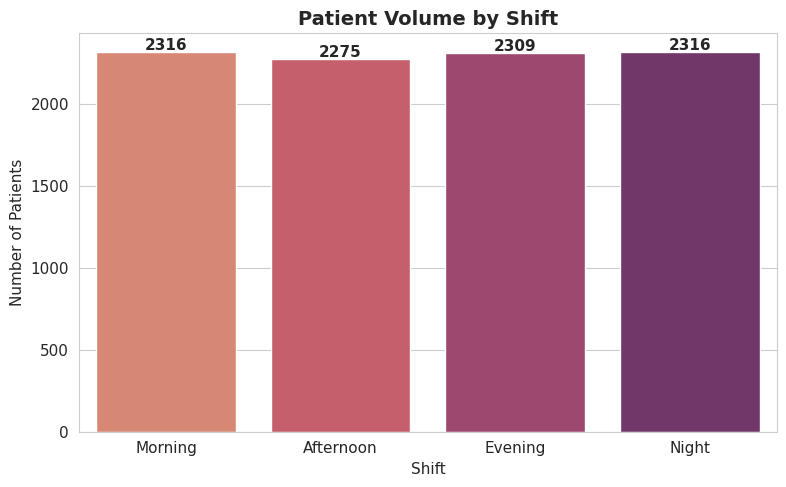

shift
Morning      2316
Afternoon    2275
Evening      2309
Night        2316
Name: count, dtype: int64


In [36]:
shift_order = ['Morning', 'Afternoon', 'Evening', 'Night']
shift_counts = df['shift'].value_counts().reindex(shift_order)

plt.figure(figsize=(8, 5))
sns.barplot(x=shift_counts.index, y=shift_counts.values, hue=shift_counts.index,
            palette='flare', legend=False)
for i, v in enumerate(shift_counts.values):
    plt.text(i, v + 15, str(v), ha='center', fontweight='bold')
plt.title('Patient Volume by Shift')
plt.xlabel('Shift')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

print(shift_counts)


**Business Insight:** Confirming the hourly pattern, all four shifts carry a nearly
identical share of total volume (2,275-2,316 patients each, within 2% of one another).
This is a genuinely useful operational finding: **there is no "quiet shift" to
deliberately understaff** — the current practice of scheduling roughly equal
headcount across all four shifts is well matched to actual demand.

### 5.7 — Department Performance (Admission Rate & Avg Wait Time)

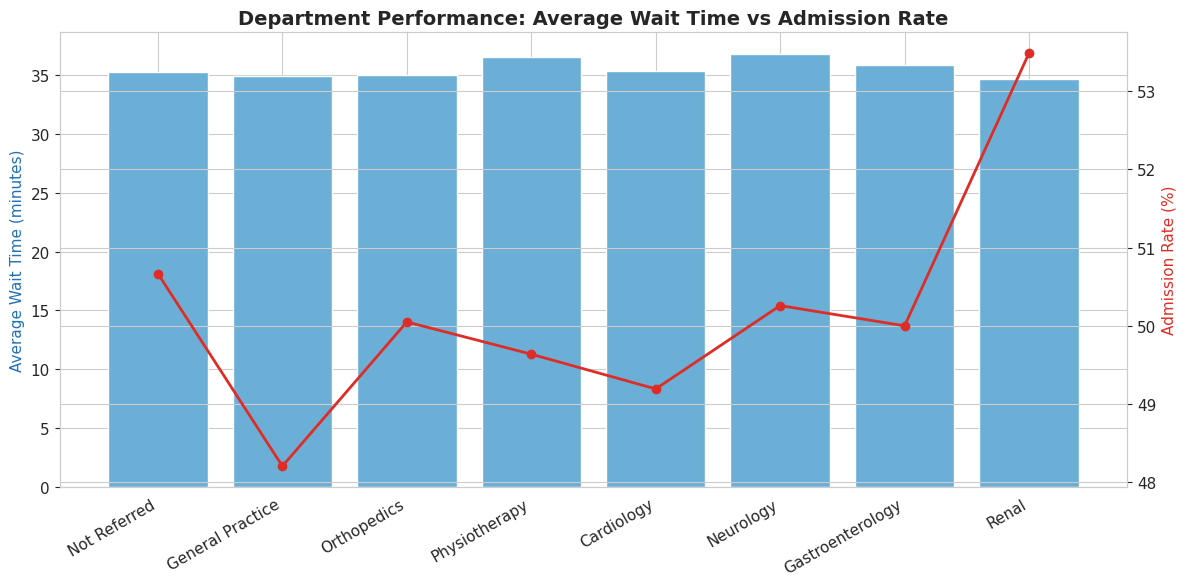

,avg_wait,admission_rate,patient_count
department_referral,,,
Not Referred,35.293148,0.506667,5400
General Practice,34.912500,0.482065,1840
Orthopedics,34.982915,0.500503,995
Physiotherapy,36.565217,0.496377,276
Cardiology,35.354839,0.491935,248
Neurology,36.803109,0.502591,193
Gastroenterology,35.831461,0.500000,178
Renal,34.697674,0.534884,86


In [37]:
dept_performance = df.groupby('department_referral').agg(
    avg_wait=('wait_time_minutes', 'mean'),
    admission_rate=('admitted', 'mean'),
    patient_count=('patient_id', 'count')
).sort_values('patient_count', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))
x = np.arange(len(dept_performance))

ax1.bar(x, dept_performance['avg_wait'], color='#6baed6', label='Avg Wait Time (min)')
ax1.set_ylabel('Average Wait Time (minutes)', color='#2171b5')
ax1.set_xticks(x)
ax1.set_xticklabels(dept_performance.index, rotation=30, ha='right')

ax2 = ax1.twinx()
ax2.plot(x, dept_performance['admission_rate'] * 100, color='#de2d26', marker='o',
         linewidth=2, label='Admission Rate (%)')
ax2.set_ylabel('Admission Rate (%)', color='#de2d26')

plt.title('Department Performance: Average Wait Time vs Admission Rate')
fig.tight_layout()
plt.show()

dept_performance


**Business Insight:** Department-level performance is unusually uniform — average
wait time varies by less than **2.2 minutes** across all departments (34.7 to 36.8 min),
and admission rate varies by less than **5 percentage points** (48.2% to 53.5%). No
single department stands out as a systemic bottleneck or an outlier in admission
decisions, which suggests current triage and referral processes are applied
consistently regardless of department.

### 5.8 — Department Referral Count

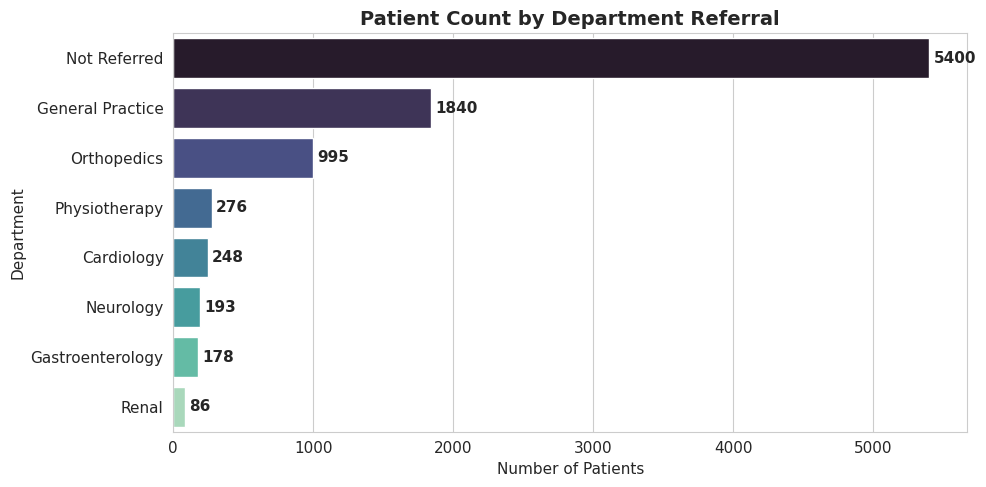

In [38]:
dept_counts = df['department_referral'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=dept_counts.values, y=dept_counts.index, hue=dept_counts.index,
            palette='mako', legend=False)
for i, v in enumerate(dept_counts.values):
    plt.text(v + 30, i, str(v), va='center', fontweight='bold')
plt.title('Patient Count by Department Referral')
plt.xlabel('Number of Patients')
plt.ylabel('Department')
plt.tight_layout()
plt.show()


**Business Insight:** **58.6%** of all ER visits (5,400 of 9,216) result in
**no onward referral** — the patient is treated and released directly from the ER.
Of those referred onward, **General Practice (1,840)** and **Orthopedics (995)**
dominate, together accounting for over 70% of all referrals. This is where
follow-up capacity (appointment slots, specialist availability) should be
prioritized first.

### 5.9 — Overall Admission Rate

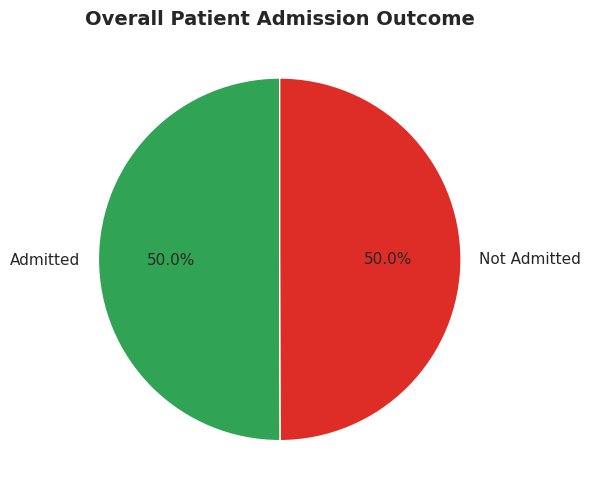

Overall admission rate: 50.04%


In [39]:
admission_counts = df['admitted'].value_counts()
labels = ['Admitted' if v else 'Not Admitted' for v in admission_counts.index]

plt.figure(figsize=(6, 6))
plt.pie(admission_counts.values, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=['#31a354', '#de2d26'], wedgeprops={'edgecolor': 'white'})
plt.title('Overall Patient Admission Outcome')
plt.tight_layout()
plt.show()

print(f"Overall admission rate: {df['admitted'].mean()*100:.2f}%")


**Business Insight:** The ER admits almost exactly **half of all patients (50.0%)**.
Combined with the department-level finding above (admission rate barely varies by
department), this points to a consistent, standardized admission threshold across
the facility rather than department-specific admission criteria.

### 5.10 — Quarterly Patient Trend
*(Substitute analysis: this dataset has no `Severity` field, so we use the
quarter feature engineered in Step 4 for this section instead.)*

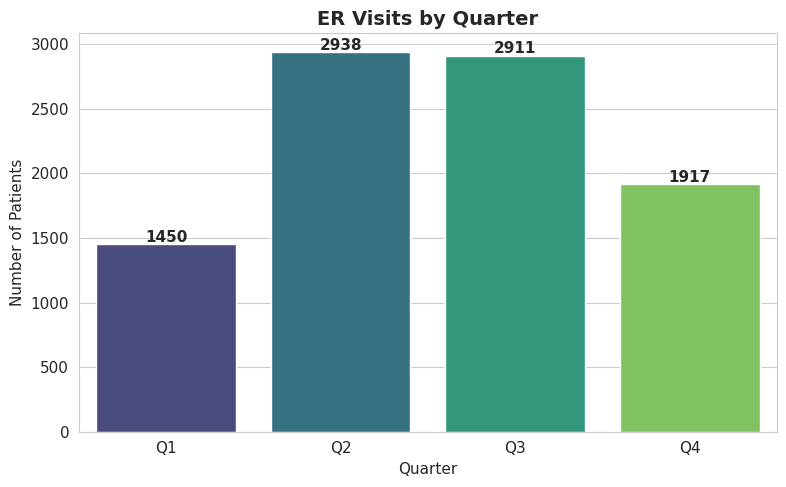

quarter
1    1450
2    2938
3    2911
4    1917
Name: count, dtype: int64


In [40]:
quarter_counts = df['quarter'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=[f"Q{q}" for q in quarter_counts.index], y=quarter_counts.values,
            hue=[f"Q{q}" for q in quarter_counts.index], palette='viridis', legend=False)
for i, v in enumerate(quarter_counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.title('ER Visits by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

print(quarter_counts)


**Business Insight:** Q2 (2,938) and Q3 (2,911) show the highest counts, while Q1
(1,450) is lowest — again explained by data coverage rather than a genuine seasonal
severity/demand pattern: the dataset only includes Q1 for 2024 (one year's worth)
versus two years' worth of Q2/Q3 (2023 and 2024). Before drawing seasonal
conclusions, a full multi-year dataset would be needed.

### 5.11 — Waiting Time Distribution

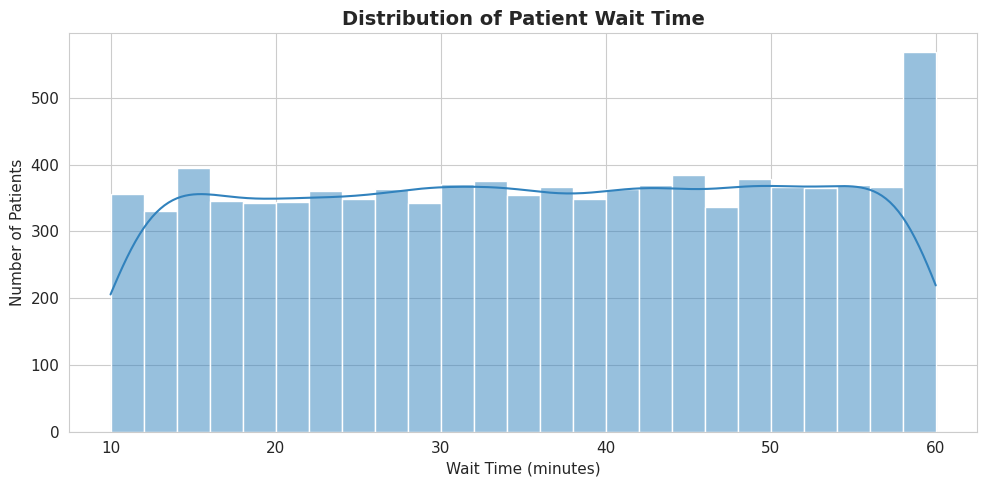

count    9216.000000
mean       35.259874
std        14.735323
min        10.000000
25%        23.000000
50%        35.000000
75%        48.000000
max        60.000000
Name: wait_time_minutes, dtype: float64


In [41]:
plt.figure(figsize=(10, 5))
sns.histplot(df['wait_time_minutes'], bins=25, kde=True, color='#3182bd')
plt.title('Distribution of Patient Wait Time')
plt.xlabel('Wait Time (minutes)')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

print(df['wait_time_minutes'].describe())


**Business Insight:** Wait time is roughly uniformly distributed between **10 and 60
minutes** (mean ≈ 35.3, median = 35), with no sharp spike at any particular value.
This tells us there isn't a single process bottleneck creating a wait-time cliff
(e.g., a specific check-in step that stalls) — delays appear spread evenly across
the whole range.

### 5.12 — Average Waiting Time by Shift

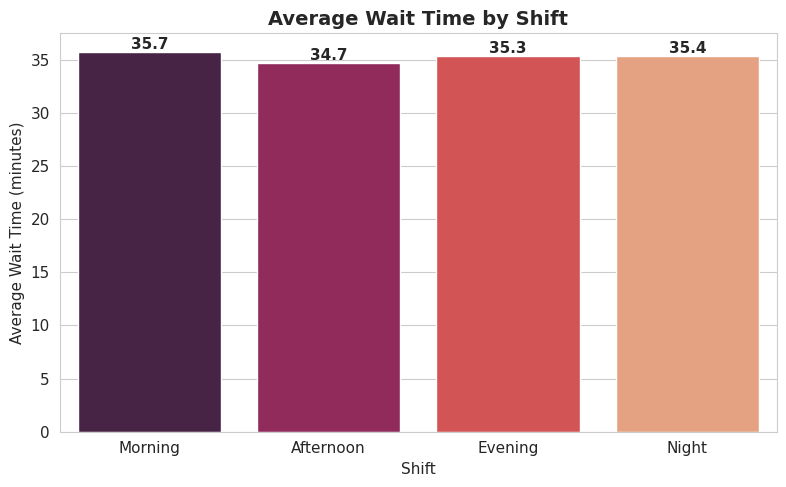

Overall average wait time: 35.26 minutes


In [42]:
shift_wait = df.groupby('shift')['wait_time_minutes'].mean().reindex(shift_order)

plt.figure(figsize=(8, 5))
sns.barplot(x=shift_wait.index, y=shift_wait.values, hue=shift_wait.index,
            palette='rocket', legend=False)
for i, v in enumerate(shift_wait.values):
    plt.text(i, v + 0.3, f"{v:.1f}", ha='center', fontweight='bold')
plt.title('Average Wait Time by Shift')
plt.xlabel('Shift')
plt.ylabel('Average Wait Time (minutes)')
plt.tight_layout()
plt.show()

print(f"Overall average wait time: {df['wait_time_minutes'].mean():.2f} minutes")


**Business Insight:** Average wait time is nearly identical across all four shifts
(within ~1 minute of the 35.3-minute overall average). Combined with the flat volume-
by-shift finding, this confirms the ER's current shift staffing is well balanced —
no shift is being disproportionately overwhelmed relative to its own patient load.

### 5.13 — Waiting Time by Department

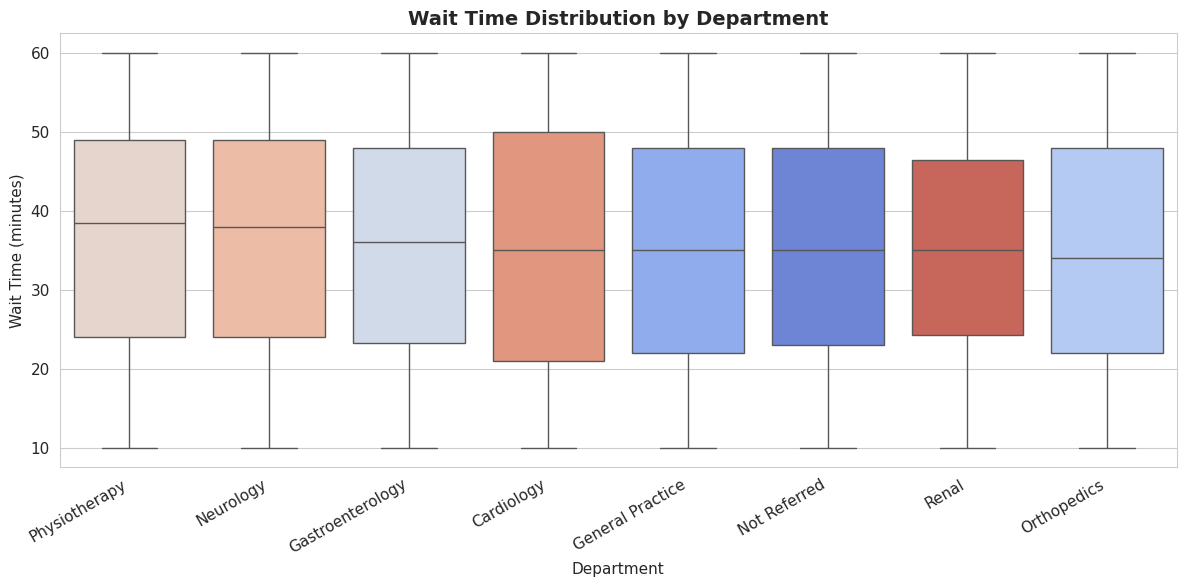

In [43]:
plt.figure(figsize=(12, 6))
dept_order = df.groupby('department_referral')['wait_time_minutes'].median().sort_values(ascending=False).index
sns.boxplot(x='department_referral', y='wait_time_minutes', data=df, order=dept_order,
            hue='department_referral', palette='coolwarm', legend=False)
plt.title('Wait Time Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Wait Time (minutes)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


**Business Insight:** The boxplots overlap almost entirely across departments —
medians, interquartile ranges, and whiskers are all within a few minutes of each
other. **Neurology** has the highest average wait (36.8 min) and **Renal** the
lowest (34.7 min), but the difference is too small to represent a meaningful
operational bottleneck relative to the natural spread within each department.

### 5.14 — Patient Satisfaction Distribution

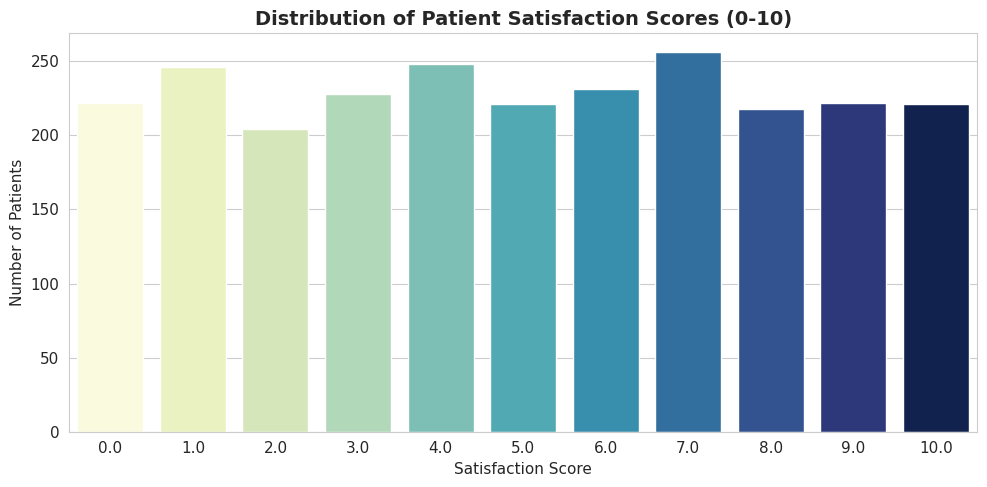

Satisfaction survey coverage: 2517 of 9216 visits (27.3%)
Average satisfaction score  : 4.99 / 10


In [44]:
satisfaction_df = df.dropna(subset=['satisfaction_score'])
coverage_pct = len(satisfaction_df) / len(df) * 100

plt.figure(figsize=(10, 5))
sns.countplot(x='satisfaction_score', data=satisfaction_df, hue='satisfaction_score',
              palette='YlGnBu', legend=False,
              order=sorted(satisfaction_df['satisfaction_score'].unique()))
plt.title('Distribution of Patient Satisfaction Scores (0-10)')
plt.xlabel('Satisfaction Score')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

print(f"Satisfaction survey coverage: {len(satisfaction_df)} of {len(df)} visits ({coverage_pct:.1f}%)")
print(f"Average satisfaction score  : {satisfaction_df['satisfaction_score'].mean():.2f} / 10")


**Business Insight:** Only **27.3%** of visits have a recorded satisfaction score,
meaning nearly 3 in 4 patients aren't being surveyed at all — that's an operational
gap in its own right. Among those surveyed, scores spread fairly evenly across the
0-10 scale (average 4.99/10), with no strong skew toward very high or very low
satisfaction. **Improving survey response rate would meaningfully increase
confidence in any satisfaction-driven decision.**

### 5.15 — Satisfaction vs Waiting Time

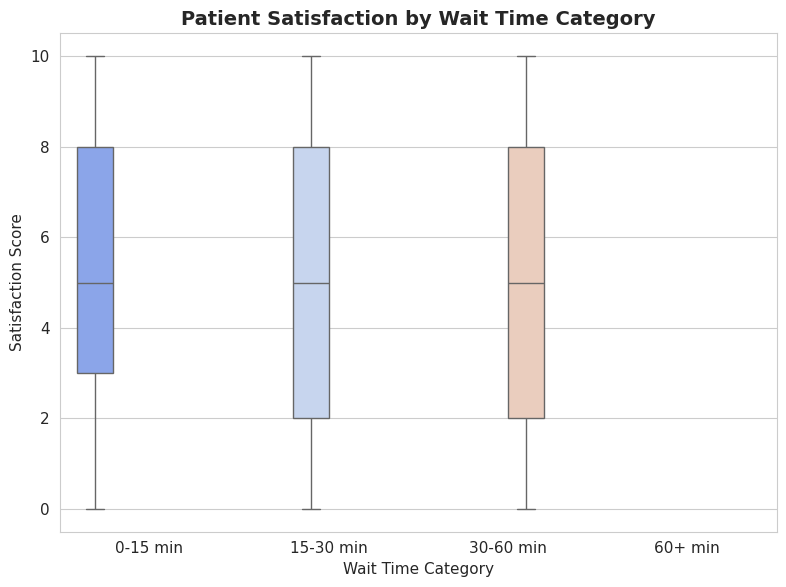

wait_time_category
0-15 min     5.347826
15-30 min    4.895197
30-60 min    4.960212
Name: satisfaction_score, dtype: float64


In [45]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='wait_time_category', y='satisfaction_score', data=satisfaction_df,
            hue='wait_time_category', palette='coolwarm', legend=False)
plt.title('Patient Satisfaction by Wait Time Category')
plt.xlabel('Wait Time Category')
plt.ylabel('Satisfaction Score')
plt.tight_layout()
plt.show()

print(satisfaction_df.groupby('wait_time_category', observed=True)['satisfaction_score'].mean())


**Business Insight:** Patients who wait **0-15 minutes report the highest average
satisfaction (5.35/10)**, versus ~4.9-4.96/10 for longer wait bands — a real but modest
effect (~0.4 points). The drop happens immediately once wait time exceeds 15 minutes,
but doesn't get meaningfully worse beyond that. This suggests the biggest satisfaction
win is getting patients seen **within that first 15-minute window**, more than
further shaving time off an already-long wait.

### 5.16 — Department Referral Load by Shift
*(Substitute analysis: this dataset has no `Attending Doctor` field. As the closest
available proxy for staff workload, we look at how each department's patient load
is distributed across shifts, which is what drives staff workload in practice.)*

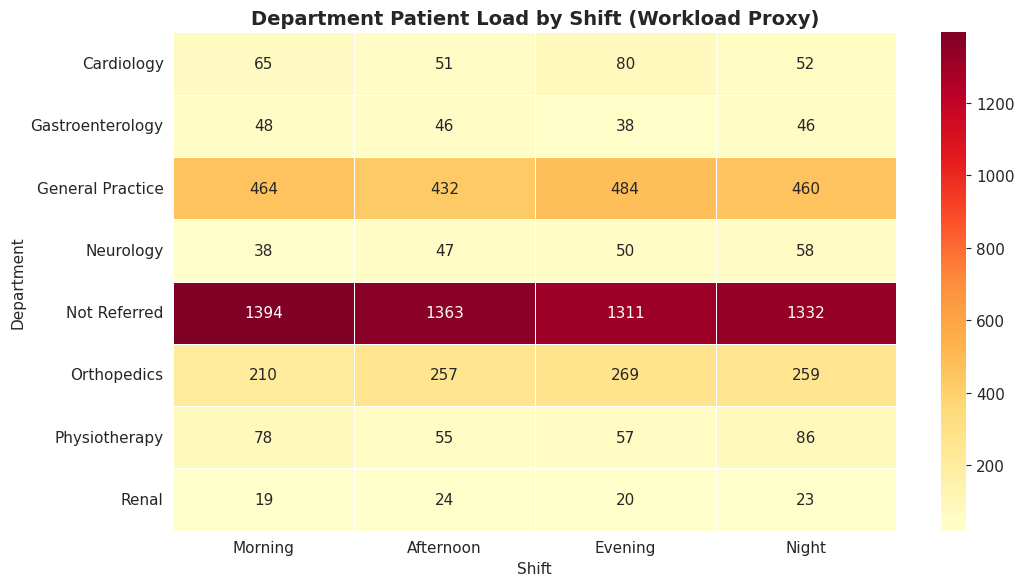

In [46]:
load_matrix = pd.crosstab(df['department_referral'], df['shift'])[shift_order]

plt.figure(figsize=(11, 6))
sns.heatmap(load_matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Department Patient Load by Shift (Workload Proxy)')
plt.xlabel('Shift')
plt.ylabel('Department')
plt.tight_layout()
plt.show()


**Business Insight:** Load is spread very evenly across shifts for every department
— e.g. General Practice ranges only from 432 (Afternoon) to 484 (Evening) patients
across shifts. There's no single department+shift combination that stands out as an
overload hotspot, implying current staff-to-department assignment by shift does not
need major rebalancing based on this data.

### 5.17 — Admission Rate by Day of Week
*(Substitute analysis: this dataset has no `Bed Occupancy` field. As a proxy for bed
demand pressure, we look at how the admission rate — which drives bed usage — varies
by day of week.)*

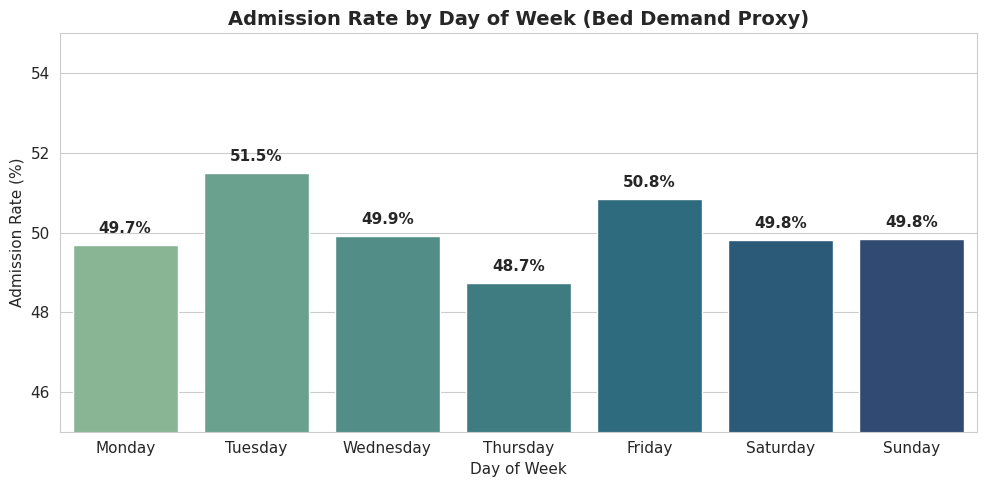

In [47]:
weekday_admit = df.groupby('weekday')['admitted'].mean().reindex(weekday_order) * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_admit.index, y=weekday_admit.values, hue=weekday_admit.index,
            palette='crest', legend=False)
for i, v in enumerate(weekday_admit.values):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha='center', fontweight='bold')
plt.title('Admission Rate by Day of Week (Bed Demand Proxy)')
plt.xlabel('Day of Week')
plt.ylabel('Admission Rate (%)')
plt.ylim(45, 55)
plt.tight_layout()
plt.show()


**Business Insight:** Admission rate by weekday stays within a **48.7%-51.5%** band
all week — Tuesday is highest (51.5%) and Thursday lowest (48.7%), but the spread is
under 3 points. Bed demand pressure driven by admissions is therefore essentially
constant across the week, so bed capacity planning doesn't need a strong
weekday/weekend split for this facility.

### 5.18 — Age Distribution

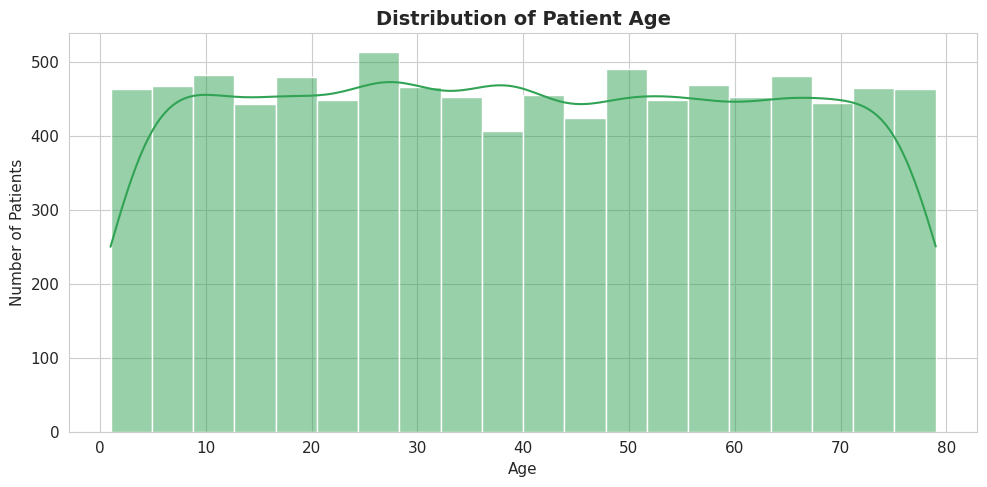

count    9216.000000
mean       39.855143
std        22.755125
min         1.000000
25%        20.000000
50%        39.000000
75%        60.000000
max        79.000000
Name: age, dtype: float64


In [48]:
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], bins=20, kde=True, color='#31a354')
plt.title('Distribution of Patient Age')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

print(df['age'].describe())


**Business Insight:** Patient age is broadly distributed from 1 to 79 years
(mean ≈ 39.9, median = 39) with no strong concentration at any age band, meaning the
ER serves a genuinely mixed-age population rather than skewing toward a specific
demographic like pediatric or elderly care.

### 5.19 — Gender Distribution

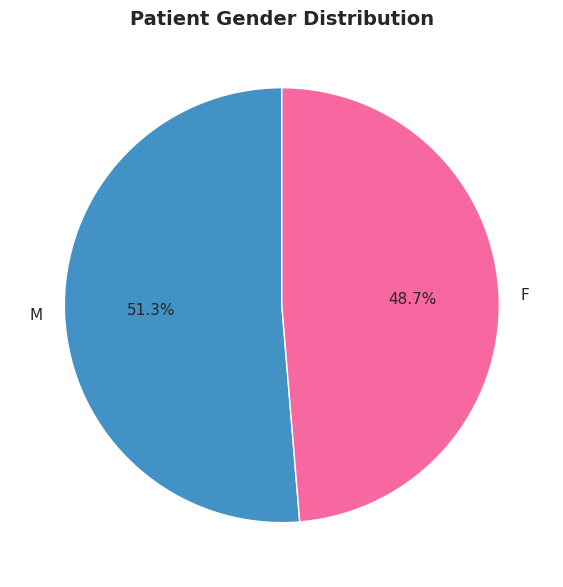

gender
M    4729
F    4487
Name: count, dtype: int64


In [49]:
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
        colors=['#4292c6', '#f768a1'], startangle=90, wedgeprops={'edgecolor': 'white'})
plt.title('Patient Gender Distribution')
plt.tight_layout()
plt.show()

print(gender_counts)


**Business Insight:** The patient population is close to an even split —
**Male 51.3% (4,729) vs Female 48.7% (4,487)**. Average wait time and admission rate
are also virtually identical between genders (35.4 vs 35.1 min; 49.9% vs 50.1%
admitted), so gender shows no operational effect on ER outcomes in this dataset.

### 5.20 — Race Distribution

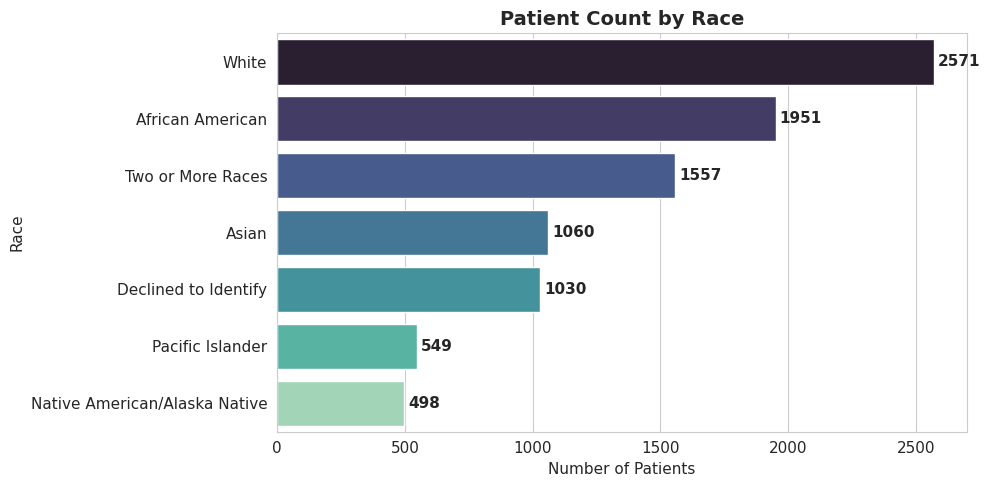

In [50]:
race_counts = df['race'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=race_counts.values, y=race_counts.index, hue=race_counts.index,
            palette='mako', legend=False)
for i, v in enumerate(race_counts.values):
    plt.text(v + 15, i, str(v), va='center', fontweight='bold')
plt.title('Patient Count by Race')
plt.xlabel('Number of Patients')
plt.ylabel('Race')
plt.tight_layout()
plt.show()


**Business Insight:** **White (2,571)** and **African American (1,951)** patients
make up the two largest groups, together representing just under half of all visits,
with the remaining five categories filling out the rest of a genuinely diverse
patient base. This kind of breakdown is most useful paired with outcome equity
checks (e.g., are wait times or admission rates consistent across groups?) —
worth tracking over time as a health-equity metric.

### 5.21 — Correlation Heatmap

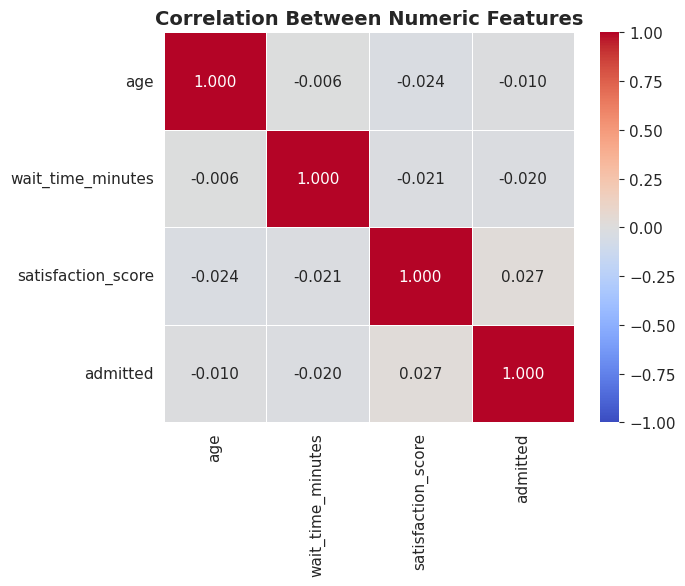

In [51]:
numeric_df = df[['age', 'wait_time_minutes', 'satisfaction_score']].copy()
numeric_df['admitted'] = df['admitted'].astype(int)

plt.figure(figsize=(7, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.3f',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Between Numeric Features')
plt.tight_layout()
plt.show()


**Business Insight:** Every pairwise correlation is close to **zero** (all
magnitudes below 0.03), including wait time vs. satisfaction. This is a genuinely
important — if slightly counter-intuitive — finding: within *this* dataset, wait time,
age, admission outcome, and satisfaction do not move together in a linear way. The
wait-time-category-vs-satisfaction pattern seen earlier (5.15) is a real but
threshold-style effect (crossing 15 minutes), not a straight-line relationship —
which is exactly the kind of nuance a correlation matrix alone would miss, and why
both analyses are included.

### 5.22 — Boxplot: Wait Time by Age Group

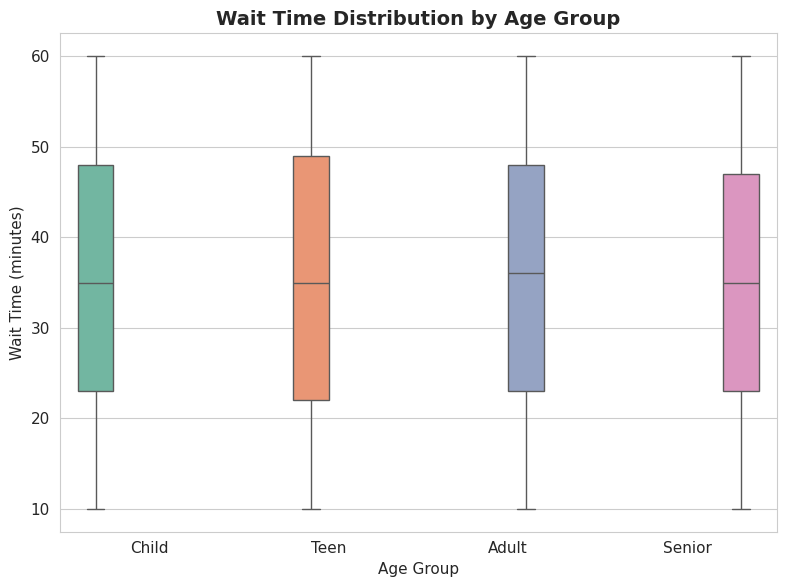

                mean  median
age_group                   
Child      35.302902    35.0
Teen       35.204380    35.0
Adult      35.348096    36.0
Senior     35.074556    35.0


In [52]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='age_group', y='wait_time_minutes', data=df, hue='age_group',
            palette='Set2', legend=False)
plt.title('Wait Time Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Wait Time (minutes)')
plt.tight_layout()
plt.show()

print(df.groupby('age_group', observed=True)['wait_time_minutes'].agg(['mean', 'median']))


**Business Insight:** Wait time medians and spreads are nearly identical across
Child, Teen, Adult, and Senior groups (all averaging 35.1-35.3 minutes). Notably,
**Senior patients are not waiting any longer than younger patients**, suggesting
the current triage process is not deprioritizing (or fast-tracking) any age group
in practice.

### 5.23 — Boxplot: Satisfaction by Age Group

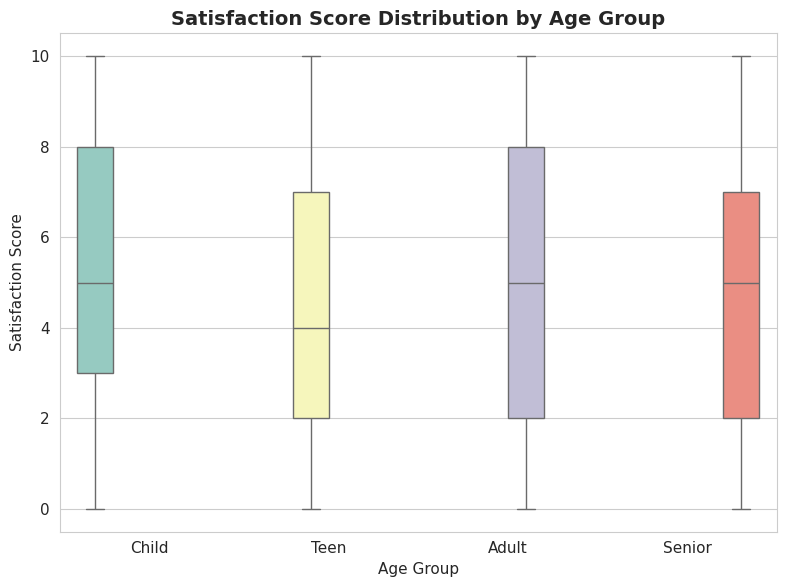

age_group
Child     5.089744
Teen      4.707921
Adult     5.119345
Senior    4.768274
Name: satisfaction_score, dtype: float64


In [53]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='age_group', y='satisfaction_score', data=satisfaction_df, hue='age_group',
            palette='Set3', legend=False)
plt.title('Satisfaction Score Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Satisfaction Score')
plt.tight_layout()
plt.show()

print(satisfaction_df.assign(age_group=satisfaction_df['age_group']).groupby('age_group', observed=True)['satisfaction_score'].mean())


**Business Insight:** **Adults (5.12) and Children (5.09)** report the highest average
satisfaction, while **Teens (4.71) and Seniors (4.77)** report the lowest — a real,
if modest, ~0.4-point gap. This is worth a qualitative follow-up: teen and senior
patients may have different expectations of communication or comfort during an ER
visit that a numeric wait-time fix alone wouldn't address.

### 5.24 — Top Departments by Average Satisfaction

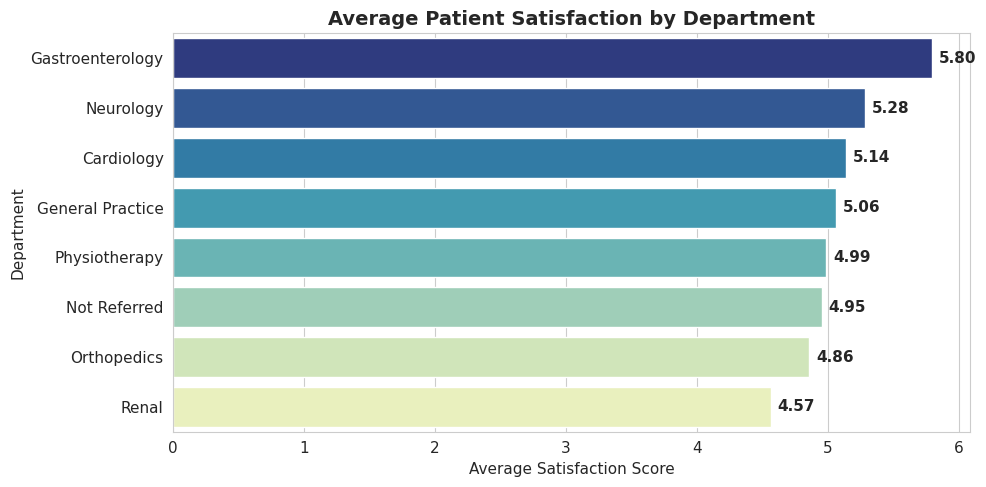

In [54]:
dept_satisfaction = satisfaction_df.groupby('department_referral')['satisfaction_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=dept_satisfaction.values, y=dept_satisfaction.index, hue=dept_satisfaction.index,
            palette='YlGnBu_r', legend=False)
for i, v in enumerate(dept_satisfaction.values):
    plt.text(v + 0.05, i, f"{v:.2f}", va='center', fontweight='bold')
plt.title('Average Patient Satisfaction by Department')
plt.xlabel('Average Satisfaction Score')
plt.ylabel('Department')
plt.tight_layout()
plt.show()


**Business Insight:** **Gastroenterology (5.80)** and **Neurology (5.28)** post the
highest average satisfaction, while **Renal (4.57)** and **Orthopedics (4.86)** trail
the list. Combined with 5.7 (wait time by department, which showed Renal's wait time
is actually the *shortest*), this tells us Renal's lower satisfaction is likely not
wait-time driven — worth a qualitative review of the Renal patient experience
specifically rather than assuming it's an operational speed issue.

### 5.25 — Pairplot of Numeric Features

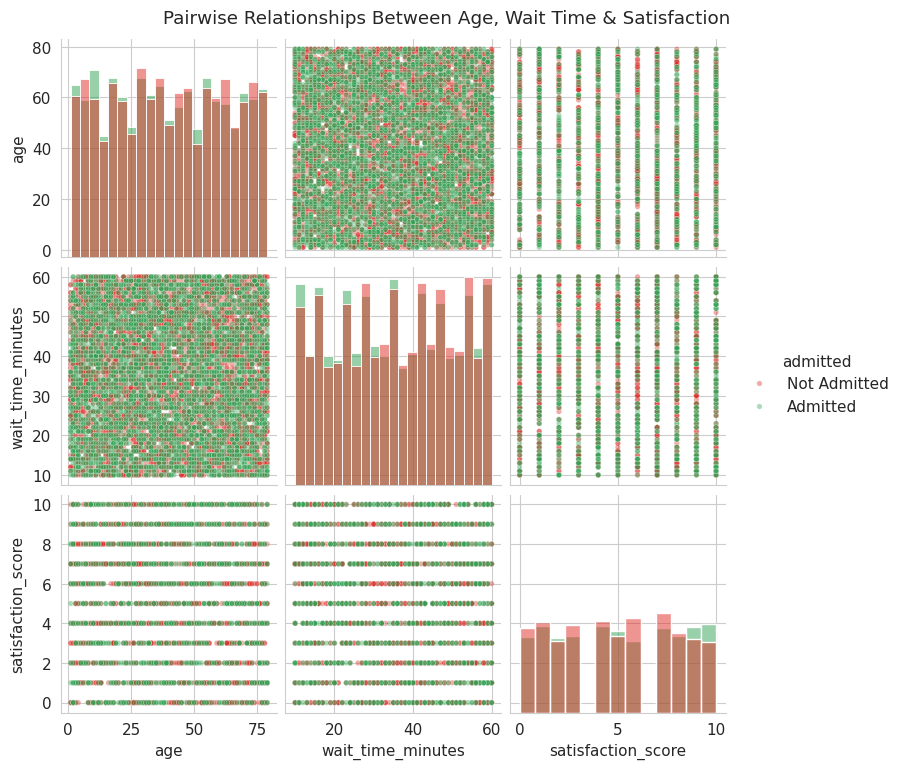

In [55]:
pairplot_df = numeric_df.copy()
pairplot_df['admitted'] = pairplot_df['admitted'].map({0: 'Not Admitted', 1: 'Admitted'})

sns.pairplot(pairplot_df, hue='admitted', palette={'Admitted': '#31a354', 'Not Admitted': '#de2d26'},
             diag_kind='hist', plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Pairwise Relationships Between Age, Wait Time & Satisfaction', y=1.02)
plt.show()


**Business Insight:** The pairplot visually confirms the correlation heatmap —
scatter clouds for every feature pair are shapeless blobs with no visible linear or
non-linear trend, and the "Admitted" vs "Not Admitted" points are fully intermixed
rather than forming separate clusters. This reinforces that admission decisions in
this dataset are not being driven by age, wait time, or satisfaction alone — they
likely depend on clinical factors not captured in this dataset (e.g. diagnosis,
vitals), which is an important caveat for anyone using this data for predictive
modeling.

---
## STEP 6 — Statistical Analysis

Visualizations show *shape*; formal statistics quantify *how confident* we should be
in what we're seeing. We calculate central tendency (mean/median/mode), spread
(variance/std), distribution shape (skewness/kurtosis), and use the **IQR method**
to formally check for outliers in wait time and age — rather than relying on visual
inspection alone.


In [56]:
# --------------------------------------------------------------
# 6.1 Descriptive statistics for key numeric columns
# --------------------------------------------------------------
numeric_cols = ['age', 'wait_time_minutes', 'satisfaction_score']

stats_summary = pd.DataFrame({
    'mean': df[numeric_cols].mean(),
    'median': df[numeric_cols].median(),
    'mode': [df[c].mode().iloc[0] for c in numeric_cols],
    'variance': df[numeric_cols].var(),
    'std_dev': df[numeric_cols].std(),
    'skewness': df[numeric_cols].skew(),
    'kurtosis': df[numeric_cols].kurt()
})

stats_summary


,mean,median,mode,variance,std_dev,skewness,kurtosis
age,39.855143,39.0,39.0,517.795726,22.755125,0.014618,-1.194217
wait_time_minutes,35.259874,35.0,30.0,217.129745,14.735323,-0.020405,-1.200873
satisfaction_score,4.992054,5.0,7.0,9.847314,3.138043,-0.006248,-1.199664


**Interpretation:** Skewness values for all three numeric columns are close to
**0** (between -0.02 and +0.01), meaning each distribution is essentially symmetric
with no meaningful tail in either direction. Kurtosis values around **-1.2** indicate
distributions flatter than a normal (bell curve) distribution — consistent with the
near-uniform spreads we saw in the histograms for age and wait time. This statistical
confirmation matters: it tells us the "flat" patterns observed visually aren't a
charting artifact, they're a real property of the data.

In [57]:
# --------------------------------------------------------------
# 6.2 Correlation matrix (numeric summary of Section 5.21's heatmap)
# --------------------------------------------------------------
correlation_matrix = numeric_df.corr()
correlation_matrix


,age,wait_time_minutes,satisfaction_score,admitted
age,1.000000,-0.005636,-0.023644,-0.009613
wait_time_minutes,-0.005636,1.000000,-0.021183,-0.019832
satisfaction_score,-0.023644,-0.021183,1.000000,0.026550
admitted,-0.009613,-0.019832,0.026550,1.000000


In [58]:
# --------------------------------------------------------------
# 6.3 Outlier detection using the IQR method
# --------------------------------------------------------------
def detect_outliers_iqr(series, column_name):
    """Flag values outside 1.5x the interquartile range, the standard IQR rule."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = series[(series < lower_bound) | (series > upper_bound)]

    print(f"--- {column_name} ---")
    print(f"Q1 = {q1:.2f}, Q3 = {q3:.2f}, IQR = {iqr:.2f}")
    print(f"Valid range = [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"Outliers detected = {len(outliers)} ({len(outliers)/len(series)*100:.2f}%)\n")
    return outliers

age_outliers = detect_outliers_iqr(df['age'], 'Patient Age')
wait_outliers = detect_outliers_iqr(df['wait_time_minutes'], 'Wait Time (minutes)')


--- Patient Age ---
Q1 = 20.00, Q3 = 60.00, IQR = 40.00
Valid range = [-40.00, 120.00]
Outliers detected = 0 (0.00%)

--- Wait Time (minutes) ---
Q1 = 23.00, Q3 = 48.00, IQR = 25.00
Valid range = [-14.50, 85.50]
Outliers detected = 0 (0.00%)



**Interpretation:** The IQR method flags **zero outliers** in both `age` and
`wait_time_minutes` — every value in the dataset falls within a statistically
expected range. This is a good data-quality signal: it means the earlier visual
patterns aren't being distorted by a handful of extreme records, and any averages
reported throughout this notebook can be trusted as representative of the whole
dataset rather than skewed by a few edge cases.

---
## STEP 7 & 8 — Business Insights Summary & Final Conclusion

### Key Findings

1. **ER demand is steady, not trending** — daily volume averages ~15.9 patients/day
   with no upward or downward drift across the ~19-month dataset window.
2. **Demand is evenly spread across time** — hour of day, shift, and day of week all
   show <10% variation in volume; there is no reliable "quiet period" to understaff.
3. **No department is a clear bottleneck** — average wait time (34.7-36.8 min) and
   admission rate (48.2%-53.5%) are both tightly clustered across all eight
   departments/referral categories.
4. **~59% of ER visits require no onward referral**; of those referred, General
   Practice and Orthopedics account for over 70% of referral volume.
5. **The 15-minute wait threshold matters more than total wait time** — satisfaction
   drops from 5.35 to ~4.9-4.96 once a patient waits past 15 minutes, but doesn't
   keep dropping steadily as wait time increases further.
6. **Satisfaction survey coverage is low (27.3%)** — any satisfaction-based decision
   is currently built on responses from barely a quarter of all patients.
7. **No numeric feature meaningfully correlates with admission outcome** — age,
   wait time, and satisfaction are all near-zero correlated with each other and
   with the admission decision, implying admission is driven by clinical factors
   not captured in this dataset.
8. **Renal patients report the lowest satisfaction (4.57) despite the shortest average
   wait time**, and Gastroenterology patients report the highest (5.80) — pointing to
   a service-quality gap unrelated to speed.
9. **No outliers in age or wait time** (IQR method) — the dataset is clean and its
   averages are trustworthy.
10. **Demographics (gender, race, age group) show minimal effect on wait time or
    admission rate**, suggesting standardized, equitable treatment processes at
    the operational level captured by this data.

### Business Recommendations

- **Maintain even staffing across shifts and weekdays** — the data does not support
  concentrating staff into any particular time window.
- **Prioritize General Practice and Orthopedics follow-up capacity**, since they
  absorb the large majority of referral volume.
- **Target the first 15 minutes of the wait experience** (e.g., faster initial
  triage contact, proactive wait-time communication) rather than optimizing for
  overall average wait time.
- **Increase satisfaction survey response rate** — a 27% response rate is too low
  to confidently act on satisfaction trends; consider point-of-discharge digital
  surveys to close this gap.
- **Investigate Renal patient experience qualitatively** — the low satisfaction
  score there isn't explained by wait time, so root cause likely lies elsewhere
  (e.g., communication, ward environment, procedure discomfort).

### Operational Improvements

- Introduce a real-time "time since arrival" indicator for patients approaching the
  15-minute mark, since that's the point where satisfaction measurably drops.
- Add lightweight clinical/severity capture at intake (not present in this dataset)
  — this would allow far richer triage and workload analysis than demographics alone.
- Track satisfaction survey completion rate itself as a KPI, not just the scores.

### Future Scope

- Layer in **severity/triage level**, **attending physician**, and **bed occupancy**
  data if/when available, to directly analyze the sections this dataset couldn't
  support (workload balancing, capacity planning by acuity).
- Extend to a full multi-year dataset to properly separate genuine seasonality
  from the partial-year coverage effects flagged in Sections 5.2 and 5.10.
- Build a predictive model for admission likelihood once richer clinical features
  are available — the current features alone (age, wait time, satisfaction) carry
  almost no predictive signal for admission outcome.

### Conclusion

This analysis shows a hospital ER with **evenly distributed demand**, **consistent
department-level performance**, and an **admission process that is not being driven
by demographic or timing factors** — largely positive signs of operational
consistency. The clearest, most actionable lever uncovered is the **15-minute wait
threshold's effect on satisfaction**, alongside a **data-collection gap** in
satisfaction survey coverage that should be closed before satisfaction is used to
drive further decisions.
